# Exploratory Data Analysis (EDA)

Note that this will be a tandem effort with main/feature_engineering.py. The more I update EDA, the more I update feature engineering, and vice versa.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
BG_COLOR = "#23272e"  
BOX_COLOR = "#61afef"  
TEXT_COLOR = "#abb2bf"  

plt.rcParams.update(
    {
        "figure.facecolor": BG_COLOR,  
        "axes.facecolor": BG_COLOR, 
        "axes.edgecolor": "#3f444a",  
        "axes.labelcolor": TEXT_COLOR,  
        "text.color": TEXT_COLOR,  
        "xtick.color": TEXT_COLOR,
        "ytick.color": TEXT_COLOR,  
        "grid.color": "#2c313c",  
    }
)

sns.set_theme(
    style="dark",
    rc={
        "figure.facecolor": BG_COLOR,
        "axes.facecolor": BG_COLOR,
        "text.color": "#abb2bf",
        "axes.labelcolor": "#abb2bf",
        "xtick.color": "#abb2bf",
        "ytick.color": "#abb2bf",
    },
)

In [3]:
df = pd.read_parquet("../data/processed/anime_data_1.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5349 entries, 0 to 5348
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   mal_id               5349 non-null   int64  
 1   title                5349 non-null   object 
 2   source               5349 non-null   object 
 3   episodes             5348 non-null   float64
 4   cohort               5349 non-null   object 
 5   genres               5349 non-null   object 
 6   demographics         5349 non-null   object 
 7   themes               5349 non-null   object 
 8   rating               5319 non-null   object 
 9   sequel               5349 non-null   bool   
 10  prequel_id           1387 non-null   float64
 11  favorites            5349 non-null   int64  
 12  score                5349 non-null   float64
 13  wc                   5349 non-null   int64  
 14  dropped              5349 non-null   int64  
 15  forum                5349 non-null   i

## Sources

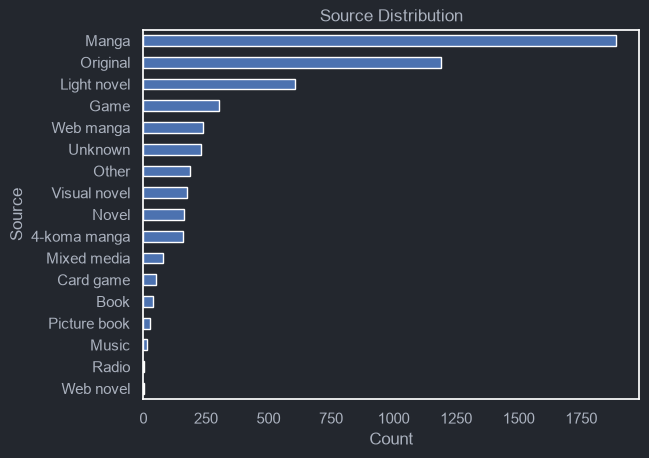

In [4]:
df['source'].value_counts(ascending=True).plot(kind='barh', edgecolor='white')
plt.title('Source Distribution')
plt.xlabel('Count')
plt.ylabel('Source')
plt.show()

## Episode Count

In [5]:
df['episodes'].describe()

count    5348.000000
mean       29.064323
std        71.651211
min         3.000000
25%        12.000000
50%        13.000000
75%        26.000000
max      1818.000000
Name: episodes, dtype: float64

Let's remove the outliers and visualize the rest via a histogram.

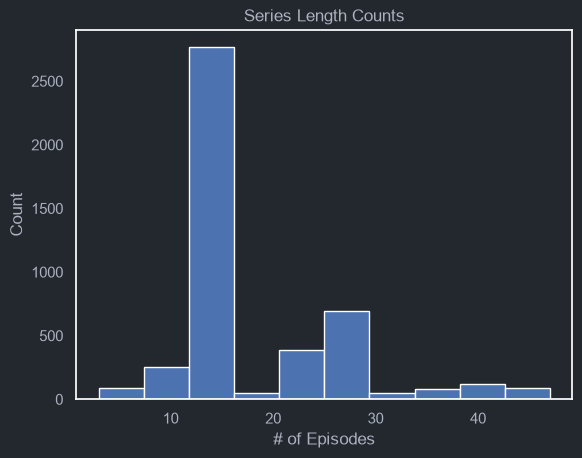

In [6]:
episode_counts = df['episodes']
q1 = episode_counts.quantile(0.25)
q3 = episode_counts.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

episode_counts_cleaned = [x for x in episode_counts if lower_bound <= x <= upper_bound]
plt.hist(episode_counts_cleaned, edgecolor='white')
plt.title('Series Length Counts')
plt.xlabel('# of Episodes')
plt.ylabel('Count')
plt.show()

Most anime are clustered around the 12-13 and 24-26 range.

## Year

In [7]:
df[['season', 'year']] = df['cohort'].str.split(" ", expand=True)
df['year'] = df['year'].astype(int)

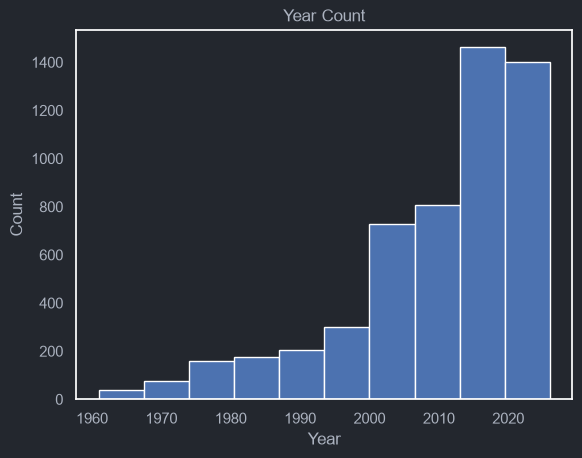

In [8]:
plt.hist(df['year'], edgecolor='white')
plt.title('Year Count')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

## Season

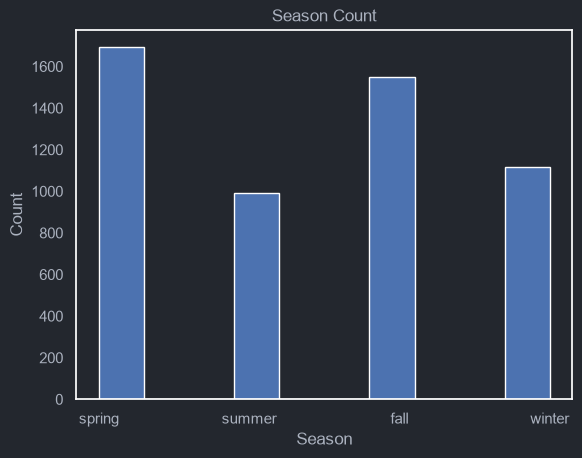

In [9]:
plt.hist(df['season'], edgecolor='white')
plt.title('Season Count')
plt.xlabel('Season')
plt.ylabel('Count')
plt.show()

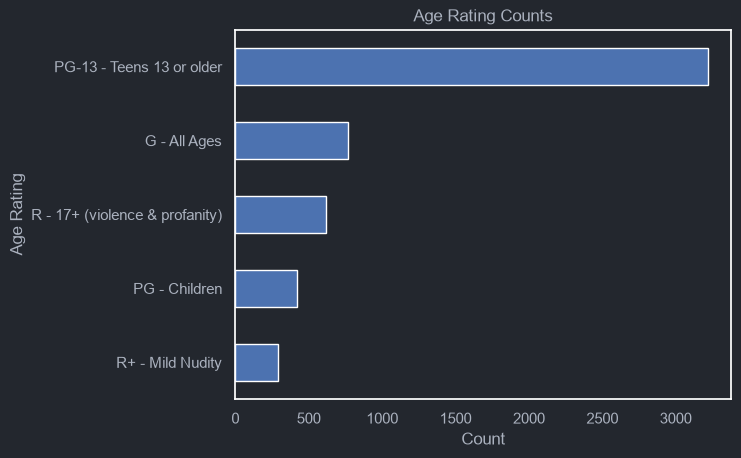

In [10]:
df['rating'].value_counts(ascending=True).plot(kind='barh', edgecolor='white')
plt.title('Age Rating Counts')
plt.xlabel('Count')
plt.ylabel('Age Rating')
plt.show()

## Score

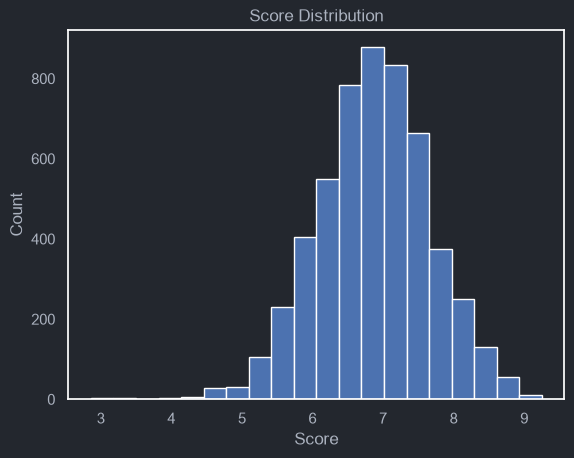

In [11]:
plt.hist(df['score'], edgecolor='white', bins=20)
plt.title('Score Distribution')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

## Watching + Completed

In [12]:
df['wc'].describe()

count    5.349000e+03
mean     1.203181e+05
std      2.921110e+05
min      1.740000e+02
25%      2.840000e+03
50%      2.145600e+04
75%      9.921200e+04
max      4.111106e+06
Name: wc, dtype: float64

Let's remove outliers and visualize:

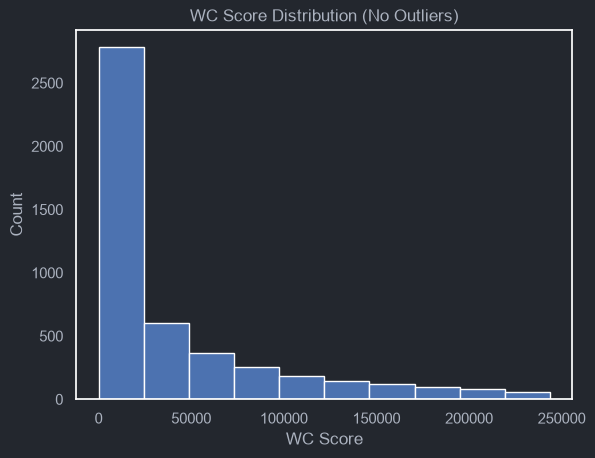

In [13]:
wc_counts = df['wc']
q1 = wc_counts.quantile(0.25)
q3 = wc_counts.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

wc_counts_cleaned = [x for x in wc_counts if lower_bound <= x <= upper_bound]

plt.hist(wc_counts_cleaned, edgecolor='white')
plt.title('WC Score Distribution (No Outliers)')
plt.xlabel('WC Score')
plt.ylabel('Count')
plt.show()

## Dropped

In [14]:
df['dropped'].describe()

count      5349.000000
mean       6696.068611
std       12719.789697
min          54.000000
25%         390.000000
50%        2117.000000
75%        7882.000000
max      248089.000000
Name: dropped, dtype: float64

Remove outliers and visualize:

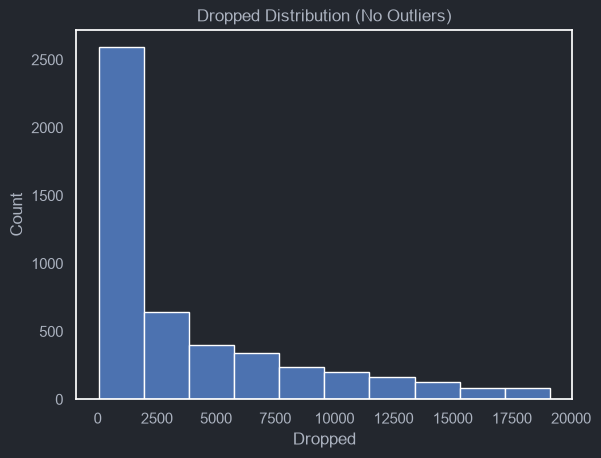

In [15]:
dropped_counts = df['dropped']
q1 = dropped_counts.quantile(0.25)
q3 = dropped_counts.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

dropped_counts_cleaned = [x for x in dropped_counts if lower_bound <= x <= upper_bound]

plt.hist(dropped_counts_cleaned, edgecolor='white')
plt.title('Dropped Distribution (No Outliers)')
plt.xlabel('Dropped')
plt.ylabel('Count')
plt.show()

## Favorites

In [16]:
df['favorites'].describe()

count      5349.000000
mean       2091.728547
std        9928.700129
min           0.000000
25%          13.000000
50%         116.000000
75%         722.000000
max      245703.000000
Name: favorites, dtype: float64

Remove outliers and visualize:

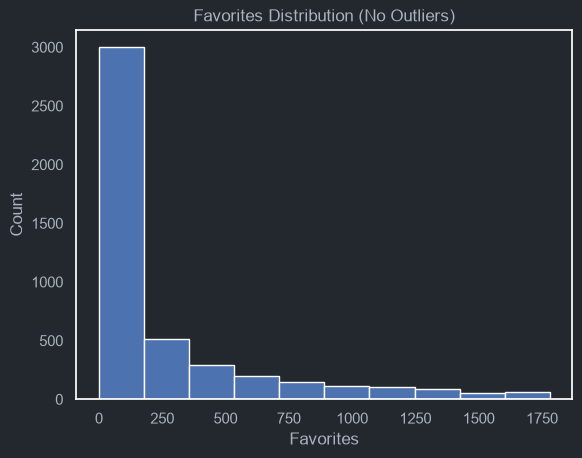

In [17]:
fav_counts = df['favorites']
q1 = fav_counts.quantile(0.25)
q3 = fav_counts.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

fav_counts_cleaned = [x for x in fav_counts if lower_bound <= x <= upper_bound]

plt.hist(fav_counts_cleaned, edgecolor='white')
plt.title('Favorites Distribution (No Outliers)')
plt.xlabel('Favorites')
plt.ylabel('Count')
plt.show()

## Forum Posts

In [18]:
df['forum'].describe()

count     5349.000000
mean       530.080950
std        790.254065
min          0.000000
25%          0.000000
50%        214.000000
75%        754.000000
max      10282.000000
Name: forum, dtype: float64

Remove outliers and visualize:

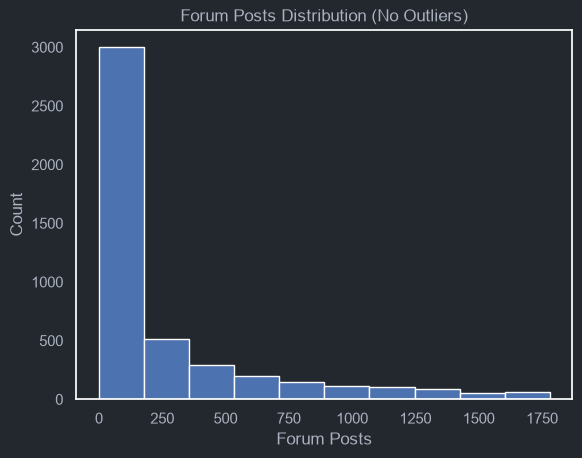

In [19]:
forum_counts = df['forum']
q1 = forum_counts.quantile(0.25)
q3 = forum_counts.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

forum_counts_cleaned = [x for x in forum_counts if lower_bound <= x <= upper_bound]

plt.hist(fav_counts_cleaned, edgecolor='white')
plt.title('Forum Posts Distribution (No Outliers)')
plt.xlabel('Forum Posts')
plt.ylabel('Count')
plt.show()

There seems to be an emerging pattern in the metrics distribution, which is somewhat to be expected: it's normal to see bigger shows have proportionally bigger counts for specific metrics such as favorites, wc score, forum posts, etc.

## Genre Counts & Score Averages

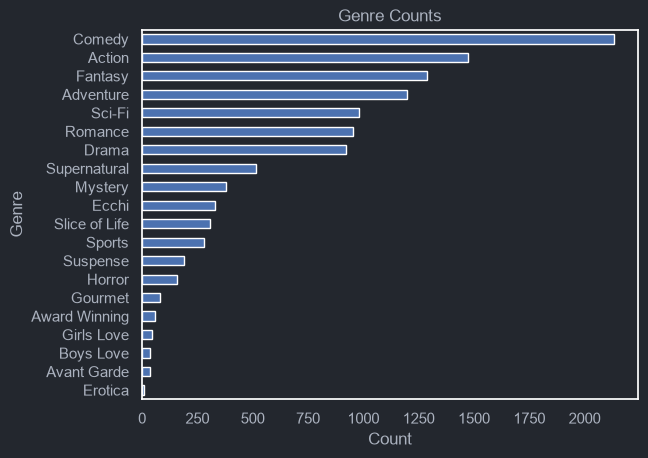

In [20]:
genre_counts = df['genres'].explode().value_counts(ascending=True)
genre_counts.plot(kind='barh', edgecolor='white')
plt.title('Genre Counts')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

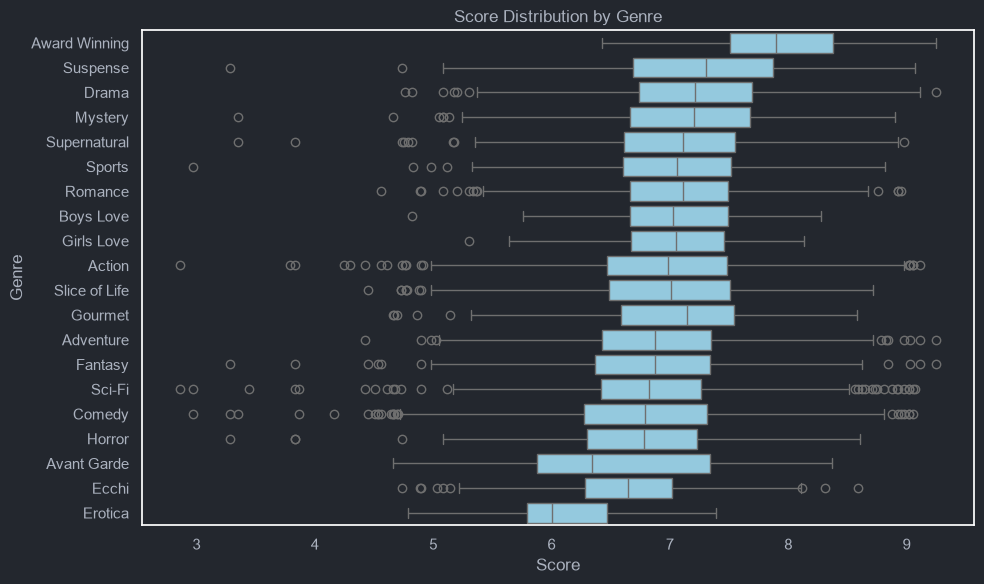

In [21]:
df_exploded = df.explode('genres').reset_index(drop=True)

genre_order = df_exploded.groupby('genres')['score'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_exploded,
    x='score',
    y='genres',
    order=genre_order,
    color='skyblue'
)

plt.title('Score Distribution by Genre')
plt.xlabel('Score')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

It's no surprise that Award-Winning has the highest average score. It's worth noting that sexual anime such as those with Ecchi or Erotica genres are rated low. While Erotica has a pretty squished distribution, Ecchi contains more outliers and is more variant. It goes to show that it's still possible to create good Ecchi anime (Ranma 1/2 as an example).

## Theme Counts & Score Averages

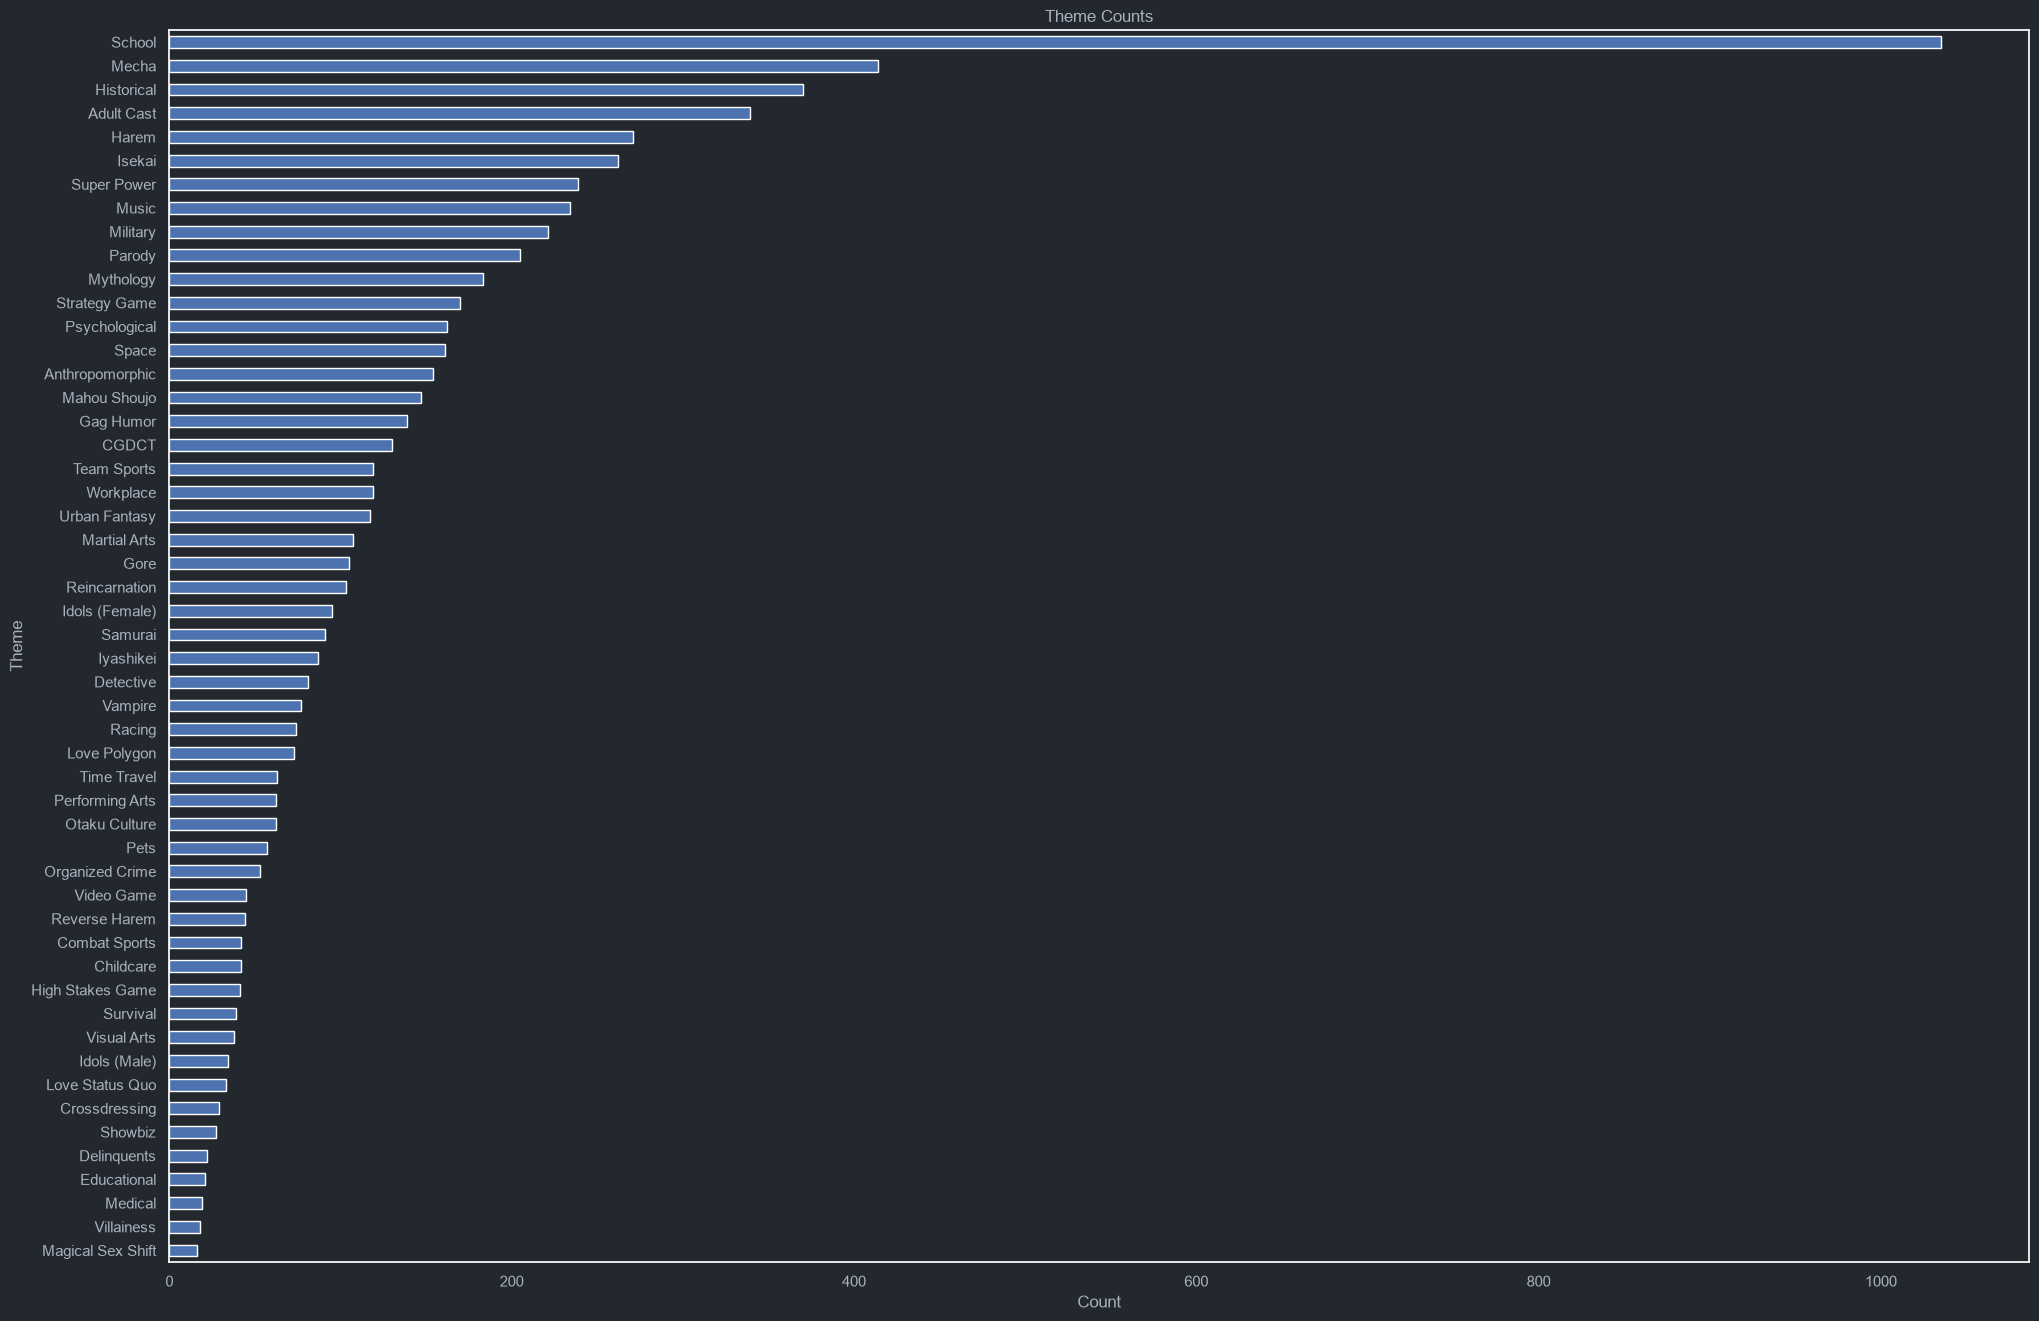

In [22]:
theme_counts = df['themes'].explode().value_counts(ascending=True)
plt.figure(figsize=(24, 16))
theme_counts.plot(kind='barh', edgecolor='white')
plt.title('Theme Counts')
plt.xlabel('Count')
plt.ylabel('Theme')
plt.show()

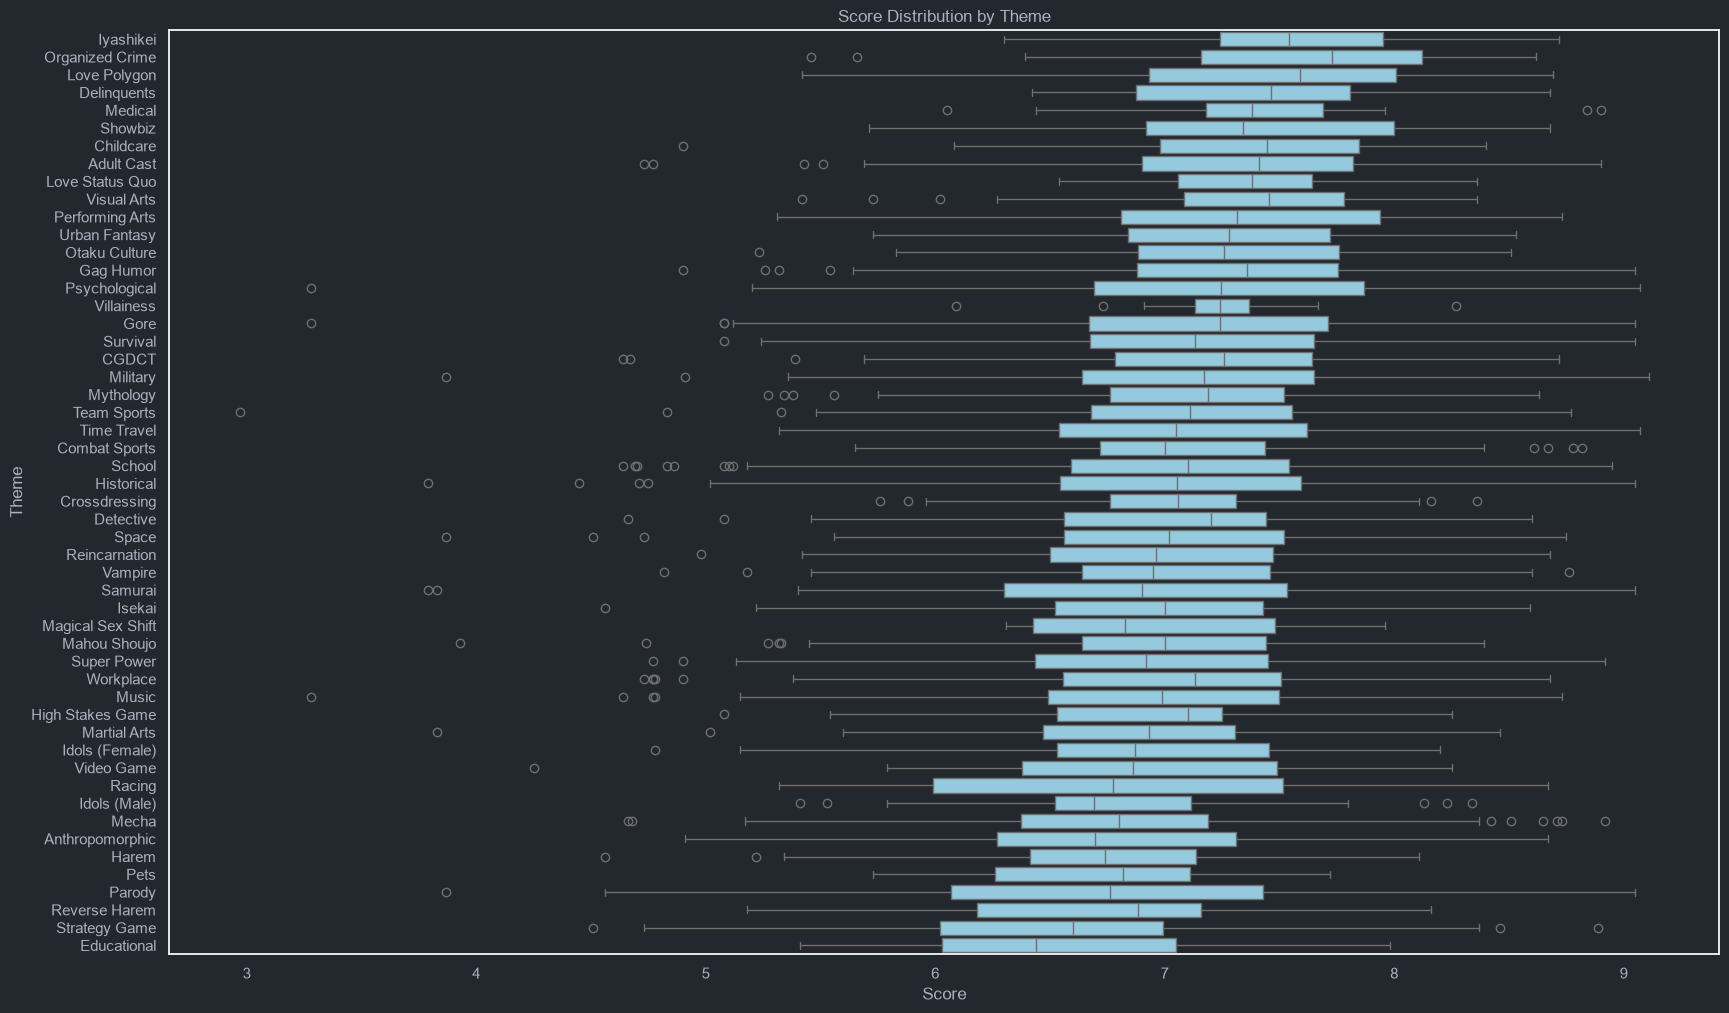

In [23]:
df_exploded = df.explode('themes').reset_index(drop=True)

theme_order = df_exploded.groupby('themes')['score'].mean().sort_values(ascending=False).index
plt.figure(figsize=(20, 12))
sns.boxplot(
    data=df_exploded,
    x='score',
    y='themes',
    order=theme_order,
    color='skyblue'
)
plt.title('Score Distribution by Theme')
plt.xlabel('Score')
plt.ylabel('Theme')
plt.show()

Iyashikei is pretty much slice of life. As expected, the community does not like harem anime that much. Some of the more surprising ones are Organized Crime and Delinquents. The Villainness theme stands out because of its low variance.

## Demographic Counts & Score Averages

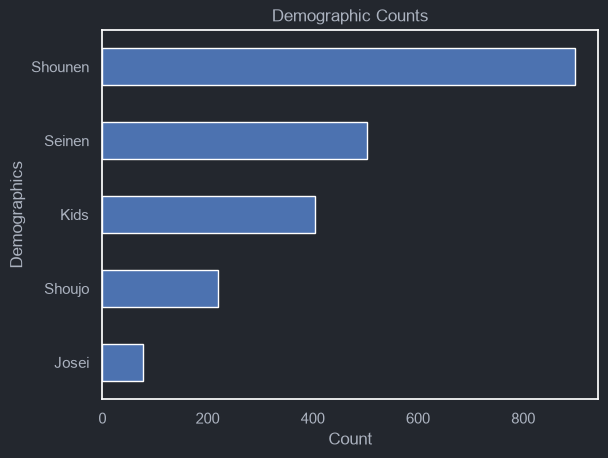

In [24]:
demo_counts = df['demographics'].explode().value_counts(ascending=True)
demo_counts.plot(kind='barh', edgecolor='white')
plt.title('Demographic Counts')
plt.xlabel('Count')
plt.ylabel('Demographics')
plt.show()

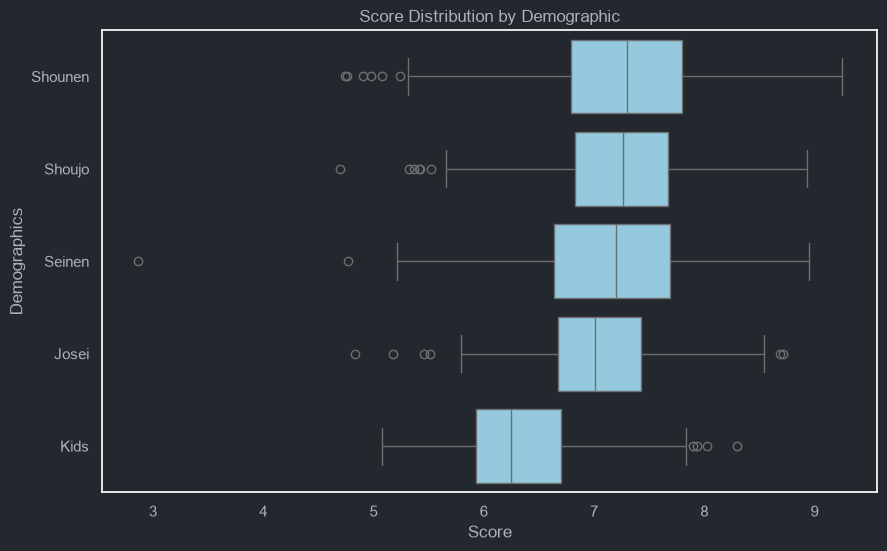

In [25]:
df_exploded = df.explode('demographics').reset_index(drop=True)

demo_order = df_exploded.groupby('demographics')['score'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_exploded,
    x='score',
    y='demographics',
    order=demo_order,
    color='skyblue'
)
plt.title('Score Distribution by Demographic')
plt.xlabel('Score')
plt.ylabel('Demographics')
plt.show()

## Yearly Score Averages

In [26]:
yearly_score = df.groupby(df['year'])['score'].mean()
yearly_score

year
1961    6.090000
1962    5.960000
1963    6.438000
1964    6.356667
1965    6.096667
          ...   
2022    6.953523
2023    7.033991
2024    7.033174
2025    6.950855
2026    7.028013
Name: score, Length: 66, dtype: float64

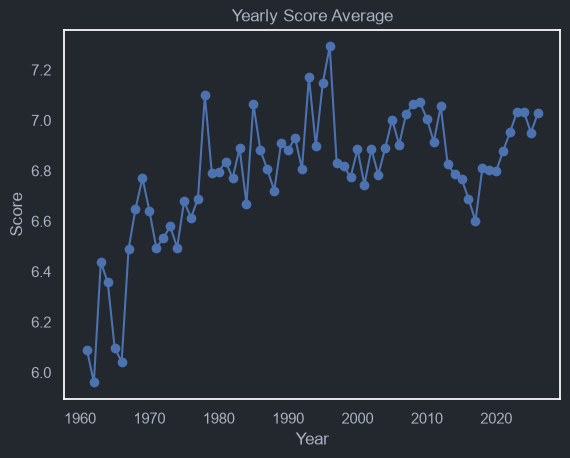

In [27]:
yearly_score.plot(kind='line', marker='o')

plt.title("Yearly Score Average")
plt.xlabel("Year")
plt.ylabel("Score")
plt.grid=True

plt.show()

## Season Score Averages

In [28]:
season_score = df.groupby(df['season'])['score'].mean()
season_score

season
fall      6.910819
spring    6.879539
summer    6.840949
winter    6.838908
Name: score, dtype: float64

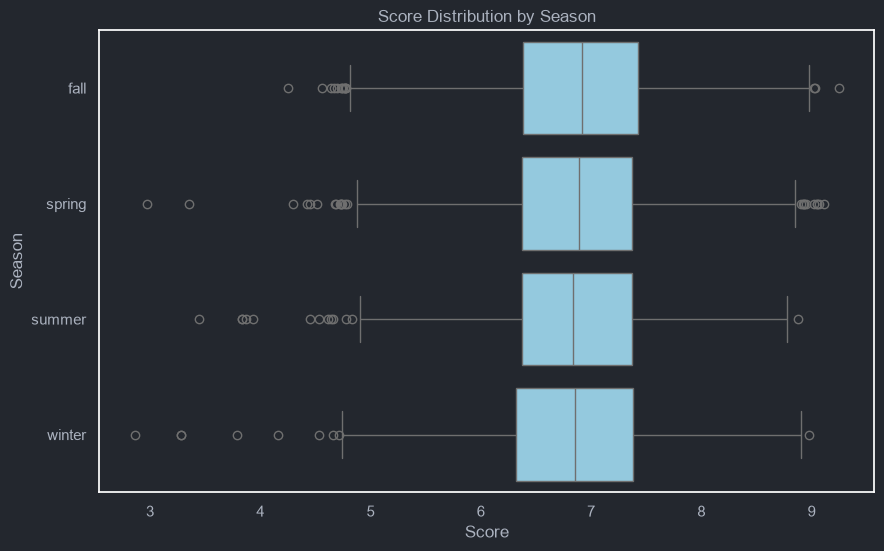

In [29]:
df_exploded = df.explode('season').reset_index(drop=True)

season_order = df_exploded.groupby('season')['score'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_exploded,
    x='score',
    y='season',
    order=season_order,
    color='skyblue'
)
plt.title('Score Distribution by Season')
plt.xlabel('Score')
plt.ylabel('Season')
plt.show()

Spring anime seems to have quite a bit of positive outliers.

## Age Rating Averages

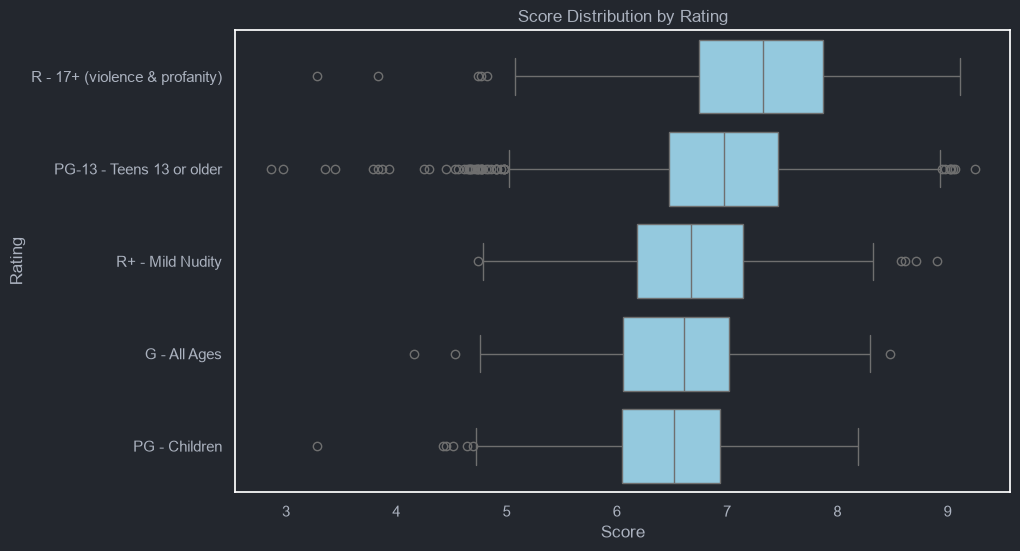

In [30]:
df_exploded = df.explode('rating').reset_index(drop=True)

rating_order = df_exploded.groupby('rating')['score'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_exploded,
    x='score',
    y='rating',
    order=rating_order,
    color='skyblue'
)
plt.title('Score Distribution by Rating')
plt.xlabel('Score')
plt.ylabel('Rating')
plt.show()

## Sequel vs. Non-sequel

In [31]:
sequel_score = df.groupby(df['sequel'])['score'].mean()
sequel_score

sequel
False    6.792928
True     7.101637
Name: score, dtype: float64

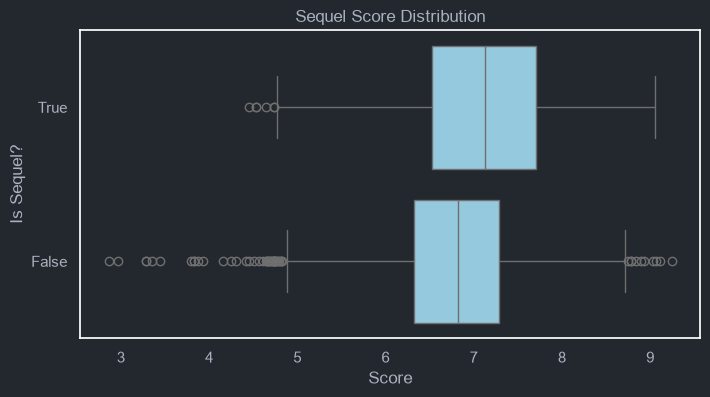

In [32]:
sequel_order = df.groupby('sequel')['score'].mean().sort_values(ascending=False).index

plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df,
    x='score',
    y='sequel',
    order=sequel_order,
    color='skyblue',
    orient='h'  
)

plt.title('Sequel Score Distribution')
plt.xlabel('Score')
plt.ylabel('Is Sequel?')
plt.show()

There are less outliers for sequels. A potential reason is a huge flop or a huge glow-up is pretty rare, while for a new series, anything can happen. The main example I can think of for a flopped sequel is Promised Neverland S2.

## Feature-Engineered EDA

We will now look at our new feature-engineered data and discover some interesting relationships.

In [33]:
df = pd.read_parquet("../data/ml_data/train_df.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4546 entries, 2053 to 860
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   source              4546 non-null   category
 1   genres              4546 non-null   object  
 2   themes              4546 non-null   object  
 3   rating              4546 non-null   category
 4   favorites           4546 non-null   float64 
 5   score               4546 non-null   float64 
 6   wc                  4546 non-null   float64 
 7   dropped             4546 non-null   float64 
 8   forum               4546 non-null   float64 
 9   adaptation_score    2300 non-null   float64 
 10  adaptation_members  2924 non-null   float64 
 11  season              4546 non-null   category
 12  year                4546 non-null   int64   
 13  prequel_score       985 non-null    float64 
 14  prequel_wc          985 non-null    float64 
 15  prequel_favorites   985 non-null    float

TypeError: 'data' must be pandas DataFrame object, not: <class 'seaborn.axisgrid.PairGrid'>

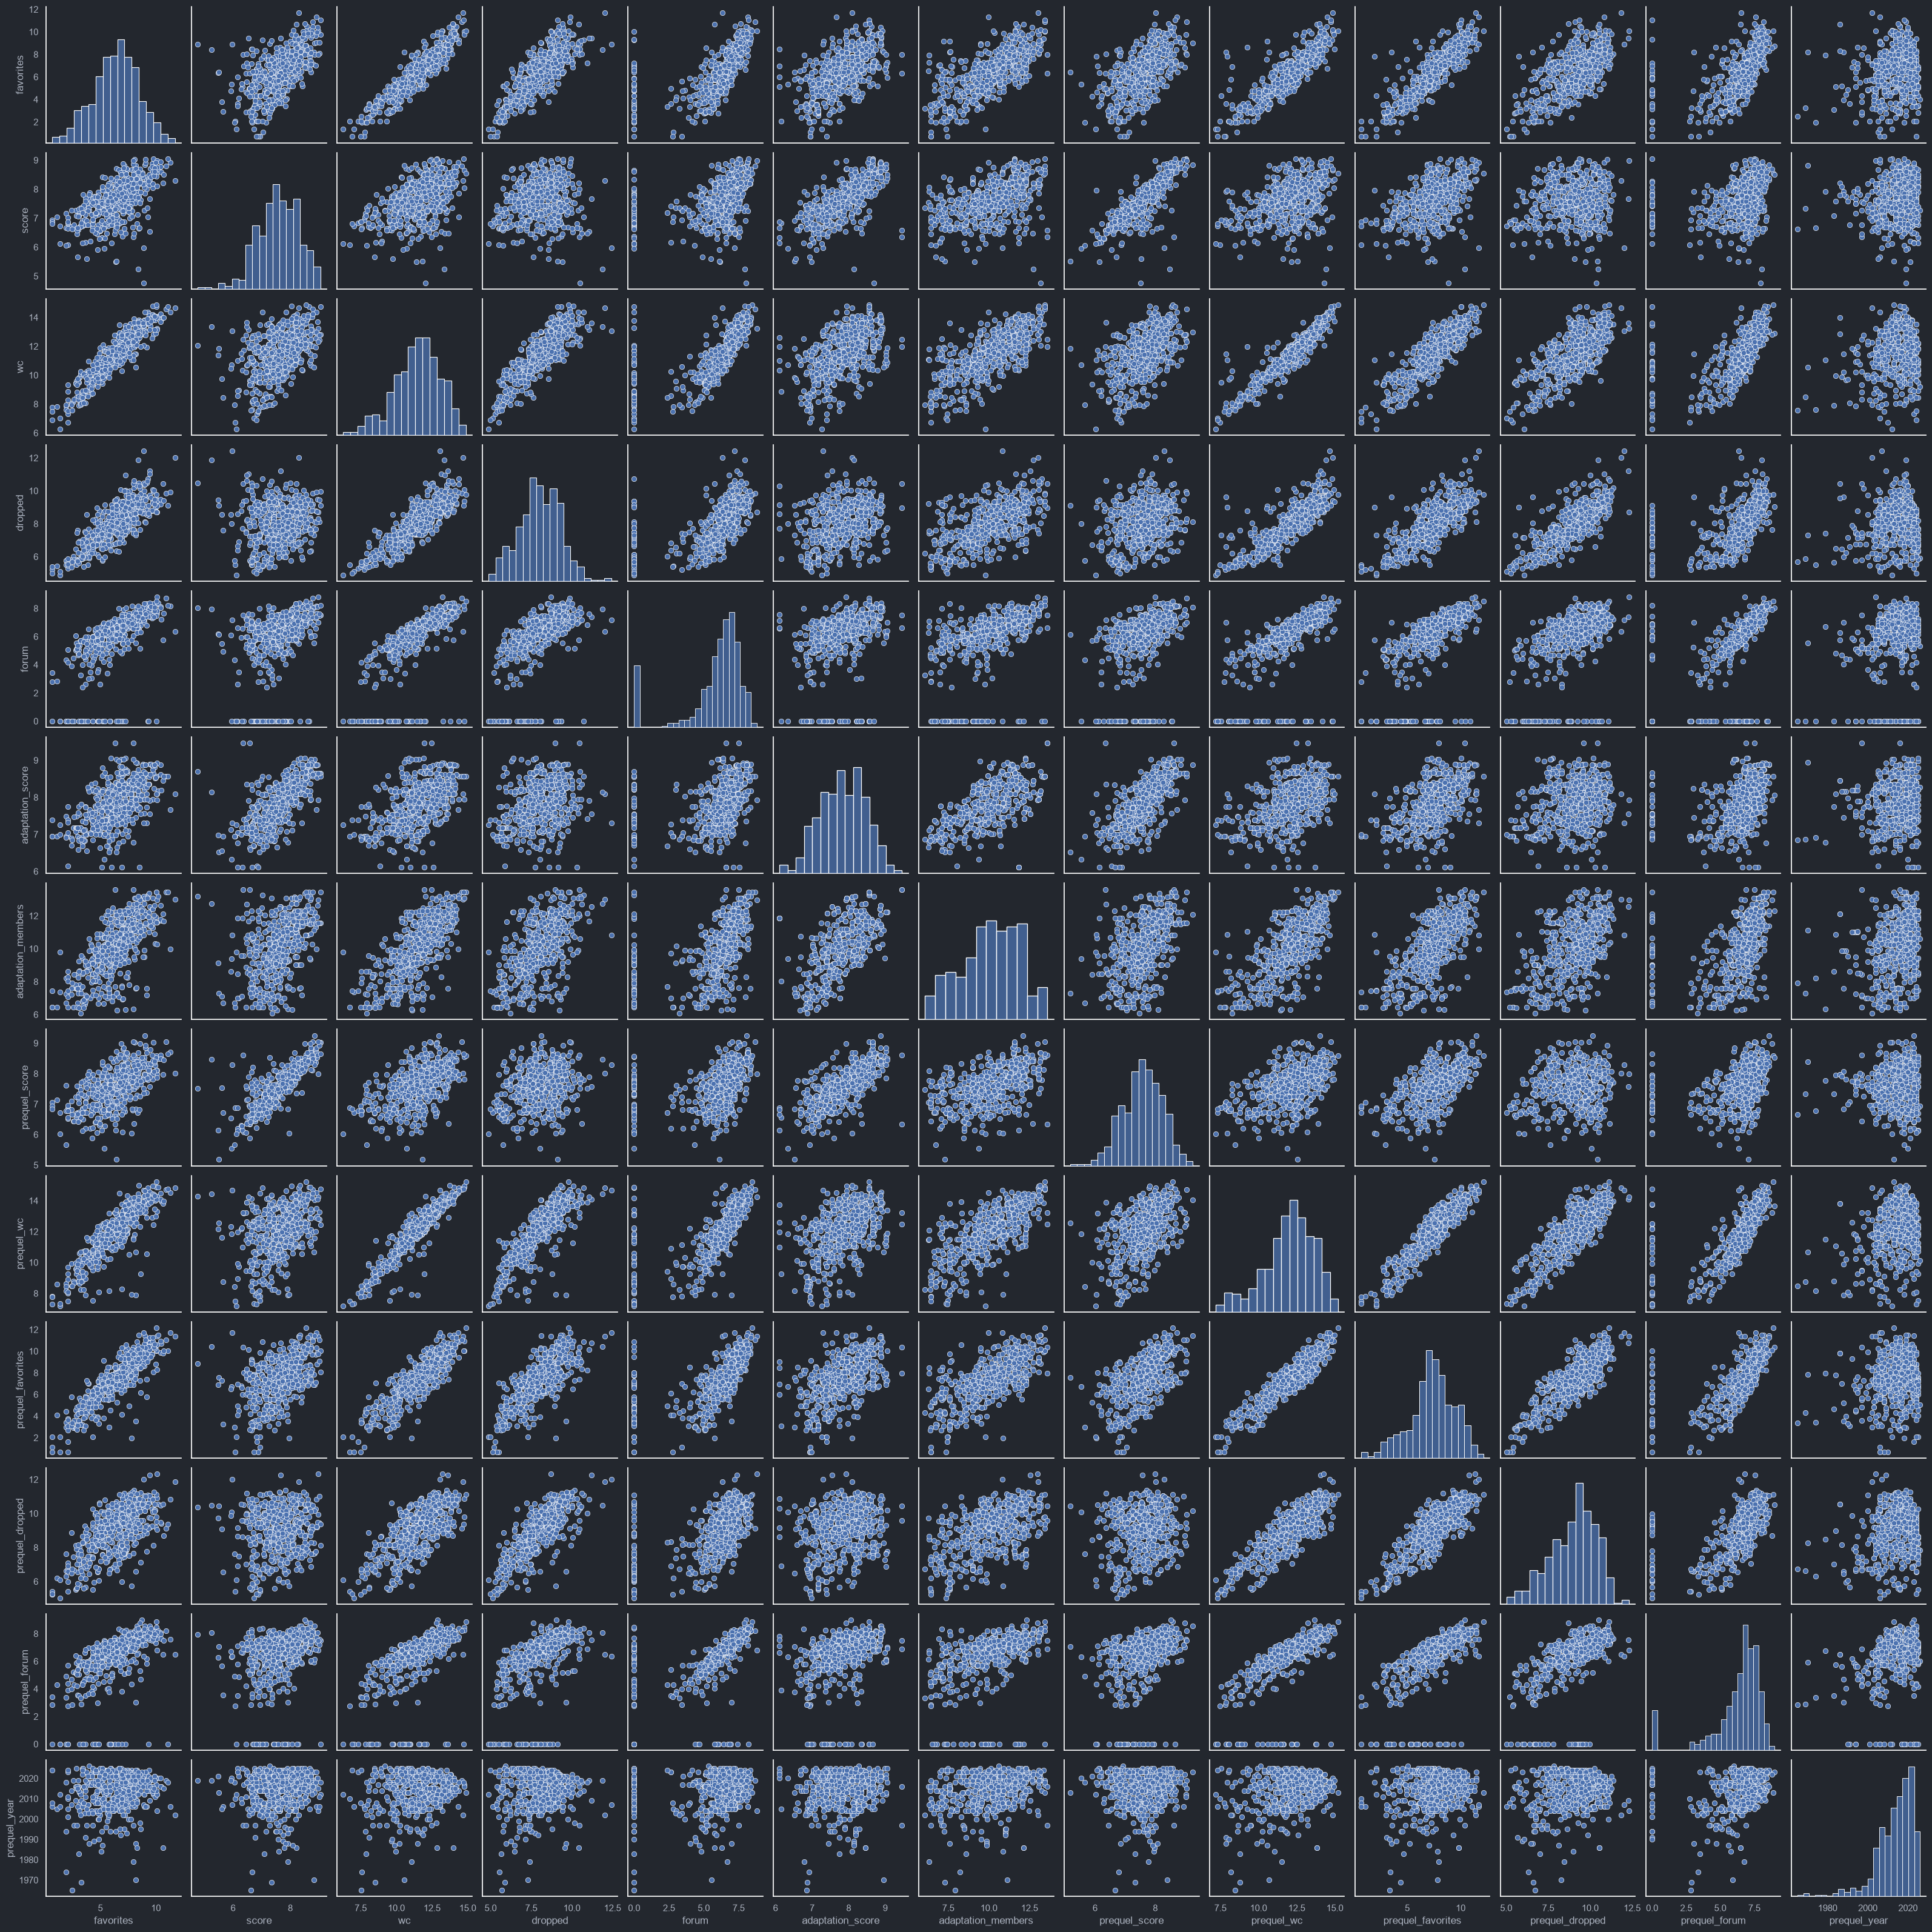

In [34]:
cols=['favorites', 'score', 'wc', 'dropped', 'forum', 'adaptation_score', 'adaptation_members',
      'prequel_score', 'prequel_wc', 'prequel_favorites', 'prequel_dropped', 'prequel_forum', 'prequel_year']

df_clean = df[cols].dropna()

sns.pairplot(sns.pairplot(df_clean))

Zooming in, we get some pretty solid trends: adaptation score vs. score, prequel score vs. score, adaptation members vs. wc, prequel wc vs. wc, etc.